# DATA 620 Final Project

## Analyzing NYC 311 Complaints: Patterns, Response Times, and Text-Based Insights

**Kevin Martin**  
**DATA 620 – Spring 2026**



## Introduction

NYC 311 is a public service system that allows residents to report issues such as noise complaints, sanitation problems, illegal dumping, and other quality-of-life concerns. This project analyzes NYC 311 complaint data to better understand patterns in complaint activity, response times, and complaint resolution trends.

This topic is meaningful to me because I have personally used the NYC 311 system since moving to Brooklyn. While some complaints appear to be resolved quickly, other situations require multiple complaints or escalation. In some cases, complaints may be marked as resolved even when the issue still exists. This project explores whether there are patterns in how complaints are handled and whether complaint types or frequency influence response times.

The project will combine data analysis, visualization, and basic text-processing techniques to explore complaint trends and identify common themes in complaint descriptions and resolutions.


## Data Loading and Preparation

In [2]:
import pandas as pd

# NYC 311 dataset API link
url = "https://data.cityofnewyork.us/resource/erm2-nwe9.csv"

# Load a manageable sample
df = pd.read_csv(url, nrows=1000)

# Display basic information
print(df.shape)

# Preview data
df.head()

(1000, 44)


,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,...,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location
0,68916156,2026-05-08T01:59:21.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,11361.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.768223,-73.761383,POINT (-73.761383470028 40.768222642098)
1,68912267,2026-05-08T01:50:58.000,NaN,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,NaN,Residential Building/House,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.638001,-73.941136,POINT (-73.941136130063 40.638001495188)
2,68912138,2026-05-08T01:50:34.000,NaN,DPR,Department of Parks and Recreation,Animal in a Park,Wildlife Sighting,Other,Park,10028.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.778633,-73.962546,POINT (-73.962546095969 40.77863290128)
3,68917758,2026-05-08T01:50:29.000,NaN,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,NaN,Residential Building/House,10034.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.869800,-73.917635,POINT (-73.917635228679 40.869800032899)
4,68919091,2026-05-08T01:49:36.000,NaN,NYPD,New York City Police Department,Illegal Parking,Blocked Hydrant,NaN,Street/Sidewalk,10467.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.885170,-73.859966,POINT (-73.859965561126 40.885169640915)


In [3]:
# Select important columns
df = df[[
    'created_date',
    'closed_date',
    'complaint_type',
    'descriptor',
    'borough',
    'status',
    'resolution_description'
]]

# Preview cleaned dataframe
df.head()

,created_date,closed_date,complaint_type,descriptor,borough,status,resolution_description
0,2026-05-08T01:59:21.000,NaN,Street Condition,Pothole,QUEENS,Open,The Department of Transportation referred this...
1,2026-05-08T01:50:58.000,NaN,Noise - Residential,Loud Music/Party,Unspecified,In Progress,NaN
2,2026-05-08T01:50:34.000,NaN,Animal in a Park,Wildlife Sighting,MANHATTAN,In Progress,NaN
3,2026-05-08T01:50:29.000,NaN,Noise - Residential,Loud Music/Party,MANHATTAN,In Progress,NaN
4,2026-05-08T01:49:36.000,NaN,Illegal Parking,Blocked Hydrant,BRONX,In Progress,NaN


In [4]:
# Convert date columns to datetime
df['created_date'] = pd.to_datetime(df['created_date'])
df['closed_date'] = pd.to_datetime(df['closed_date'])

# Calculate response time in hours
df['response_time_hours'] = (
    df['closed_date'] - df['created_date']
).dt.total_seconds() / 3600

# Preview results
df[['created_date', 'closed_date', 'response_time_hours']].head()

,created_date,closed_date,response_time_hours
0,2026-05-08 01:59:21,NaT,NaN
1,2026-05-08 01:50:58,NaT,NaN
2,2026-05-08 01:50:34,NaT,NaN
3,2026-05-08 01:50:29,NaT,NaN
4,2026-05-08 01:49:36,NaT,NaN


In [5]:
# Count complaint statuses
df['status'].value_counts()

,count
status,
Closed,492
In Progress,403
Open,105


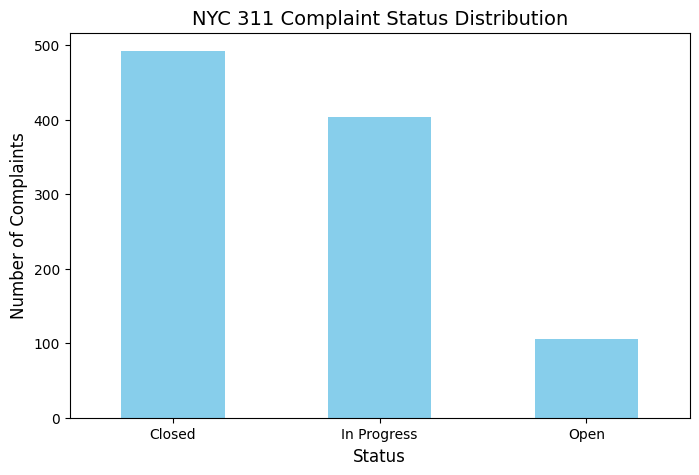

In [6]:
import matplotlib.pyplot as plt

# Count statuses
status_counts = df['status'].value_counts()

# Create bar chart
plt.figure(figsize=(8,5))
status_counts.plot(kind='bar', color='skyblue')

# Labels and title
plt.title("NYC 311 Complaint Status Distribution", fontsize=14)
plt.xlabel("Status", fontsize=12)
plt.ylabel("Number of Complaints", fontsize=12)

plt.xticks(rotation=0)

plt.show()

In [7]:
# Remove rows with missing response times
response_df = df.dropna(subset=['response_time_hours'])

# Summary statistics
response_df['response_time_hours'].describe()

,response_time_hours
count,492.000000
mean,0.829315
std,0.691163
min,0.000000
25%,0.289444
50%,0.626667
75%,1.204375
max,4.416667


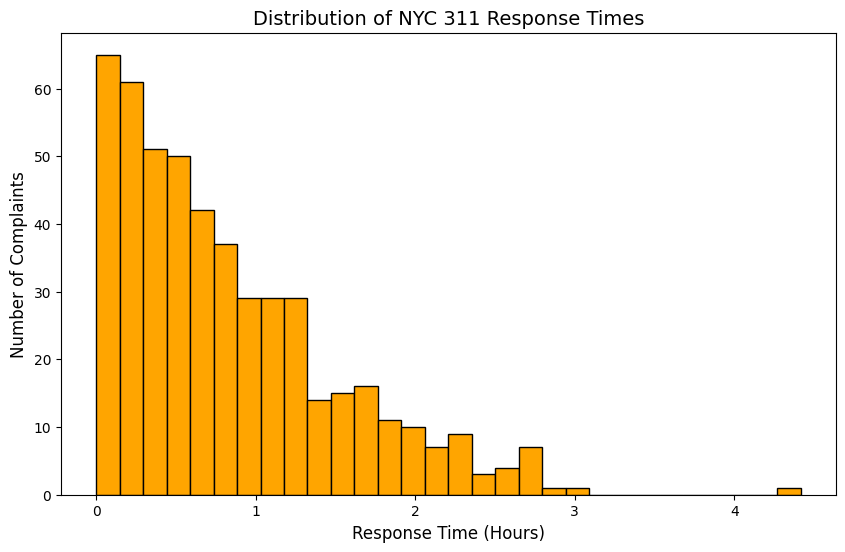

In [8]:
# Histogram of response times
plt.figure(figsize=(10,6))

plt.hist(response_df['response_time_hours'], bins=30, color='orange', edgecolor='black')

# Labels and title
plt.title("Distribution of NYC 311 Response Times", fontsize=14)
plt.xlabel("Response Time (Hours)", fontsize=12)
plt.ylabel("Number of Complaints", fontsize=12)

plt.show()

In [9]:
# Average response time by complaint type
avg_response = (
    response_df.groupby('complaint_type')['response_time_hours']
    .mean()
    .sort_values()
    .head(10)
)

# Display results
avg_response

,response_time_hours
complaint_type,
Street Condition,0.000000
Water System,0.000000
Noise - House of Worship,0.118565
Traffic,0.137222
Drug Activity,0.182917
Vendor Enforcement,0.334815
Non-Emergency Police Matter,0.566389
Noise - Vehicle,0.659954
Encampment,0.682083


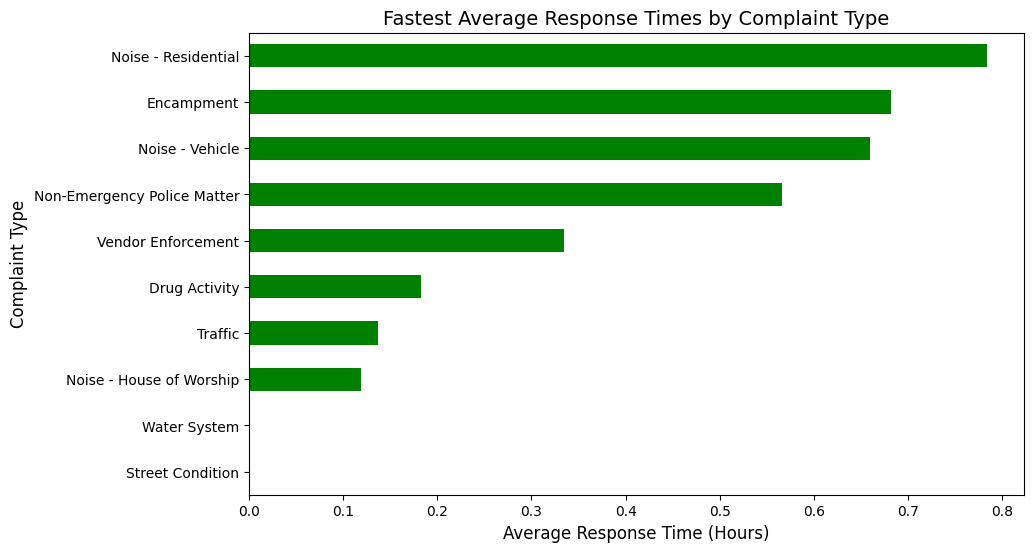

In [10]:
# Plot fastest complaint types
plt.figure(figsize=(10,6))

avg_response.plot(kind='barh', color='green')

# Labels and title
plt.title("Fastest Average Response Times by Complaint Type", fontsize=14)
plt.xlabel("Average Response Time (Hours)", fontsize=12)
plt.ylabel("Complaint Type", fontsize=12)

plt.show()

In [11]:
from collections import Counter
import re

# Combine all descriptors into one text string
text = ' '.join(df['descriptor'].dropna().astype(str))

# Convert to lowercase
text = text.lower()

# Remove punctuation
text = re.sub(r'[^\w\s]', '', text)

# Split into words
words = text.split()

# Count most common words
word_counts = Counter(words)

# Show top 10 words
word_counts.most_common(10)

[('loud', 385),
 ('musicparty', 285),
 ('parking', 97),
 ('talking', 91),
 ('bangingpounding', 86),
 ('blocked', 83),
 ('hydrant', 71),
 ('access', 56),
 ('posted', 53),
 ('sign', 53)]

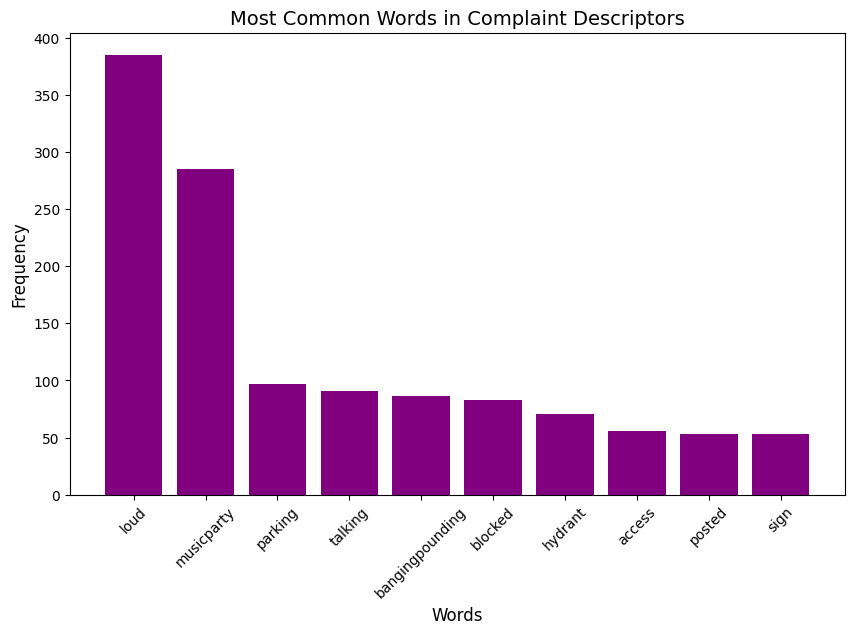

In [12]:
# Convert top words into dataframe
top_words = pd.DataFrame(
    word_counts.most_common(10),
    columns=['word', 'count']
)

# Plot most common words
plt.figure(figsize=(10,6))

plt.bar(top_words['word'], top_words['count'], color='purple')

# Labels and title
plt.title("Most Common Words in Complaint Descriptors", fontsize=14)
plt.xlabel("Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.xticks(rotation=45)

plt.show()

## Key Findings

Several interesting patterns appeared during the analysis of NYC 311 complaint data.

Most complaints in the dataset were marked as closed, while a smaller number remained open or in progress. However, some complaint types appeared to close extremely quickly, with certain categories showing average response times close to zero hours. This raises questions about how complaints are processed and whether closure time always reflects actual issue resolution.

The response time analysis also showed that noise-related complaints, particularly residential noise complaints, were among the faster-closing complaint categories. This was especially interesting because my own experience using the NYC 311 system involved repeated noise complaints that did not always appear to be fully resolved.

The text-processing analysis revealed that words related to loud music and parties appeared much more frequently than other complaint descriptor terms. This suggests that noise complaints make up a significant portion of the service requests in this sample dataset.

Overall, the analysis demonstrates how data visualization and text-processing techniques can help uncover patterns in public service systems and raise important questions about response effectiveness and complaint resolution.

## Reflection and Interpretation

One possible explanation for the very fast closure times of some complaints is that certain complaint types may be routed to another agency and marked as closed within the NYC311 system once the referral process is completed. For example, noise complaints may be forwarded to law enforcement for handling, which could explain why some complaints appear to close quickly even if the underlying issue continues.

This raises an important distinction between a complaint being marked as “closed” within the system and the issue actually being resolved from a resident’s perspective. From personal experience, I have observed situations where complaints were marked as resolved even though the issue still appeared to exist afterward.

At the same time, additional investigation would be needed to fully understand how agencies manage complaint status updates and whether rapid closure times reflect efficient service, automated processing, referral workflows, or other operational factors. These observations are intended as interpretations based on the available data rather than conclusions about wrongdoing or system misuse.

I also reviewed the [NYC311](https://portal.311.nyc.gov/about-nyc-311/) service request process documentation to better understand how complaints move through the system. According to NYC311, complaints are sent in real time to the responsible agency, which may perform inspections, repairs, enforcement actions, or other responses before closing the request. This process may help explain why some complaints appear to close very quickly in the dataset. In some cases, a complaint may be considered closed after it has been routed or processed by the responsible agency, even if the resident still feels the underlying issue was not fully resolved.

## Borough Analysis

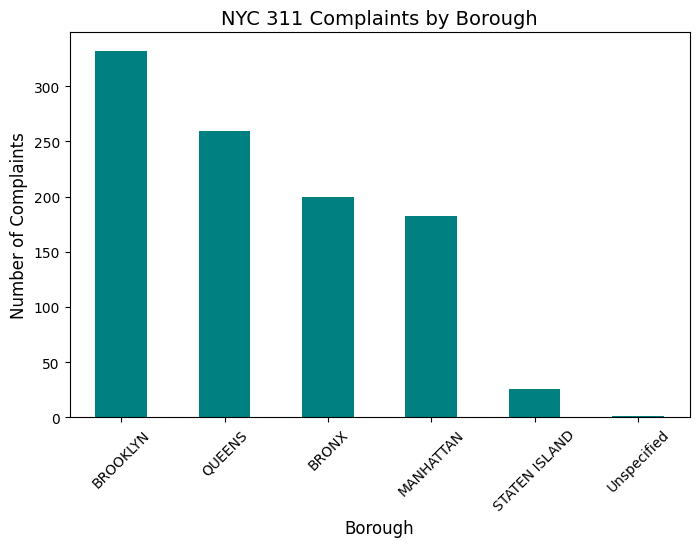

In [13]:
# Count complaints by borough
borough_counts = df['borough'].value_counts()

# Plot complaints by borough
plt.figure(figsize=(8,5))

borough_counts.plot(kind='bar', color='teal')

# Labels and title
plt.title("NYC 311 Complaints by Borough", fontsize=14)
plt.xlabel("Borough", fontsize=12)
plt.ylabel("Number of Complaints", fontsize=12)

plt.xticks(rotation=45)

plt.show()

### Borough Analysis Interpretation

The borough analysis showed differences in the number of NYC 311 complaints across boroughs in the sample dataset. Higher complaint counts may reflect factors such as population density, housing patterns, noise activity, sanitation concerns, or differences in reporting behavior among residents.

This visualization helps provide additional context for understanding how quality-of-life complaints may vary across different areas of New York City. It also demonstrates how geographic analysis can be combined with response-time and text-processing analysis to better understand public service request patterns.

## Conclusion

This project explored NYC 311 complaint data using data analysis, visualization, and text-processing techniques to better understand complaint trends, response times, and complaint resolution patterns. By analyzing complaint statuses, response times, borough distributions, and complaint descriptor text, several meaningful patterns emerged from the dataset.

One of the most interesting findings was that some complaint categories appeared to close very quickly, including noise-related complaints and certain infrastructure-related complaint types. While fast closure times may reflect efficient workflows, they may also reflect how complaints are routed, processed, or transferred between agencies within the NYC311 system. This highlights the important difference between a complaint being marked as closed and a resident feeling that the issue was fully resolved.

The text-processing analysis also showed that words related to loud music and parties appeared far more frequently than many other complaint descriptors, suggesting that noise-related complaints represent a significant portion of service requests in this sample. Combined with the response-time analysis, these findings helped create a broader picture of how NYC311 complaints may be handled across different complaint categories.

Overall, this project demonstrated how public datasets can be used to better understand city service systems and identify patterns that may not be immediately obvious from raw data alone. It also reinforced the importance of combining technical analysis with critical interpretation when working with real-world data.